In [5]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from scipy.ndimage import gaussian_filter1d
from scipy.stats import hmean

mode= "DC" # DC
powerID= 14
outPutFile= False
# Load MATLAB file
file_name= f'matpower/test_data/DC_case{powerID}_.mat' #14, 118, 57, 30
file_path= f'data/paper_2/results{powerID}.xlsx' # DC
out_path= f'data/paper_2/detect_results{powerID}.xlsx' # DC
if mode == "AC":
    file_path= f"data/ac/results{powerID}_AC.xlsx"
# Access a variable inside the .mat file
_, _, H, A, _= ioFile.read_mat_power(file_name, normalize= False)
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 2e-2
numTrain= m+1
# trainDataNp= powerfun.generate_random_power_flow(H, m)
pfData, _=ioFile.read_excel_power(file_path, id1= 0, id2= 0)
# simuX= np.random.randn(H.shape[1], pfData.shape[0]).T
# pfData= (H@simuX.T).T
phaseData= (np.linalg.pinv(H)@pfData.T).T
normalPfData= H.dot(phaseData.T).T
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noisePfData= pfData.copy()+noiseVector*stdOfNoise
trainDataNp= noisePfData[:numTrain, :]
testDataNp= noisePfData[numTrain:, :]
plotTimeSeries= False
if plotTimeSeries:
    plt.figure(figsize=(16, 6))
    for i in range(testDataNp.shape[1]):
        plt.plot(testDataNp[:, i], label=i)
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


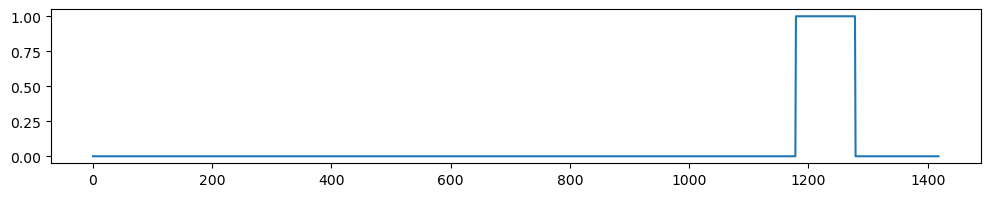

In [6]:
if mode == "AC":
    pfData, _= ioFile.read_excel_power(file_path, 0, 0)
else:
    attackPeriod= np.linalg.norm((normalPfData-pfData)[numTrain:, ], axis= 1)>1e-5 
    plt.figure(figsize=(12, 2)) 
    plt.plot(attackPeriod) 
tmpPdData= pfData+noiseVector*1e-6
wholeRight= tmpPdData[:numTrain, :].T.dot(tmpPdData[:numTrain, :])
spaningTreeList, leftLinksSet= csp.get_spanning_tree(trainDataNp, rankH, m)
cycleList, treeLinks= csp.get_cycle_and_tree(spaningTreeList, leftLinksSet, wholeRight, m)
_, cSpaceClean, _= resd.cycle_residual(pfData[:numTrain, :], rankH, m, pfData[numTrain:, :], cycleList)
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T

In [7]:
links= set(range(m))-set(treeLinks)
def links_in_cycle(linksSet, cycleSet):
    return linksSet.intersection(cycleSet)
lenOfLocated= [] 
for i in links:# select on link only
    for j in links:
        if i != j:
            attackedLinks= {i}
            setE= set(links)
            cyclesAttack= []
            cyclesFree= []
            for cycle in cycleList:
                if len(links_in_cycle(attackedLinks, cycle)):
                    cyclesAttack.append(cycle)
                else:
                    cyclesFree.append(cycle)
            for ci in range(len(cyclesAttack)):
                for cj in range(ci+1, len(cyclesAttack)):
                    combineCyc= cyclesAttack[ci].union(cyclesAttack[cj])-cyclesAttack[ci].intersection(cyclesAttack[cj])
                    if len(links_in_cycle(attackedLinks, combineCyc))==0:
                        setE-= combineCyc
            for cj in cyclesFree:
                setE-= cj
            lenOfLocated.append(len(setE))
print(np.mean(lenOfLocated))
print(np.std(lenOfLocated))
print(np.max(lenOfLocated))
print(np.min(lenOfLocated))

1.8421052631578947
0.6698906348083082
3
1


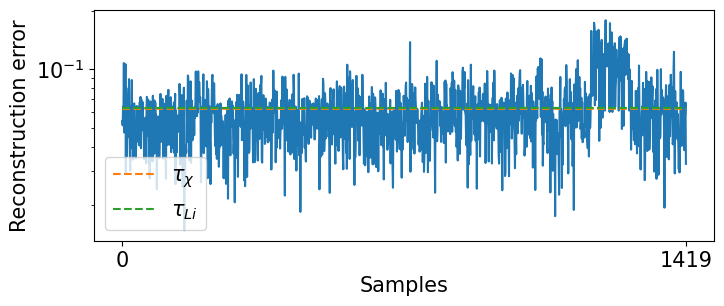

In [8]:
df = m-n+1  # degrees of freedom
confidence_level = 0.80
# Upper critical value (i.e., chi-square value such that P(X <= value) = 0.95)
thresholdChi= np.sqrt(chi2.ppf(confidence_level, df)*np.square(stdOfNoise))

errorC, cSpace, _= resd.cycle_residual(trainDataNp, rankH, m, testDataNp, cycleList= cycleList)
residualH, nullH= resd.svd_residual(trainDataNp, rankH, testDataNp)
residualT= resd.true_residual(H, m, testDataNp)

residualC= np.linalg.norm(errorC, axis= 0)

thresholdLi= threshold_li(residualC)
# residualC= np.square(residualC)/(stdOfNoise**2)
# residualT= np.square(residualT)/(stdOfNoise**2)
# residualH= np.square(residualH)/(stdOfNoise**2)
plt.figure(figsize=(8, 3))
fontsize= 15
# smoothedresidualC = gaussian_filter1d(residualC, sigma= 10, axis=0, mode='reflect')
plt.plot(residualC)
# plt.plot(smoothedresidualC)
plt.plot([thresholdChi for _ in residualC] , "--", label = r"$\tau_{\chi}$")
plt.plot([thresholdLi for _ in residualC] , "--", label = r"$\tau_{Li}$")
# plt.plot(residualCCp , label = "cycle space o", alpha= 0.6)
# plt.plot(residualH , label = "SVD-based detector", alpha= 0.6)
# plt.plot(residualHCp , label = "null space o", alpha= 0.6)
# plt.plot(residualT , label = "T space", alpha= 0.6)
# plt.plot(residualTCp , label = "T space o", alpha= 0.6)
plt.xlabel("Samples", fontsize= fontsize)
plt.yscale("log")
plt.xticks([0, testDataNp.shape[0]], [0, testDataNp.shape[0]], fontsize= fontsize)
plt.yticks(fontsize= fontsize)
# plt.ylim(0, 0.01)
plt.ylabel("Reconstruction error", fontsize= fontsize) 
# startIdx= np.nonzero(attackPeriod)[0][0]
# endIdx= np.nonzero(attackPeriod)[0][-1]
# plt.fill_between(range(startIdx, endIdx), 0, 0.2, alpha=0.4, color= "grey")
plt.legend(loc= 'lower left', fontsize= fontsize)
if outPutFile:
    df = pd.read_excel(file_path, engine='openpyxl')
    for i in range(errorC.shape[0]):
        df[f"pf_{1+i}"]= errorC[i, :]
    df.to_excel(out_path, index=False, engine='openpyxl')

In [141]:
falsePositives= []
for i in range(20, testDataNp.shape[0]-numTrain):
    testDataNp= testDataNp[numTrain: numTrain+i , :]
    residualC, cSpace, _= resd.cycle_residual(trainDataNp, rankH, m, testDataNp, cycleList= cycleList)
    attackPeriodTmp= attackPeriod[numTrain: numTrain+i]
    _, _, falsePositive0, thresholdChi= threshold.chi_2_threshold(residualC, attackPeriodTmp, confidence_level, df, stdOfNoise)
    _, _, falsePositive1, thresholdLi= threshold.li_threshold(residualC, attackPeriodTmp)
    _, _, falsePositive2, _= threshold.joint_threshold(residualC, attackPeriodTmp, thresholdChi, thresholdLi)
    falsePositives.append([falsePositive0, falsePositive1, falsePositive2])
falsePositives= np.array(falsePositives)

0.013632506166628427


ValueError: operands could not be broadcast together with shapes (21,) (12,0) 

In [25]:
plt.figure(figsize=(8, 4))
fontsize= 15
legends= [0.002, 0.005, 0.01, 0.02]

for i, residualC in enumerate(residualCs):
    # color = plt.cm.Blues(0.8-i*0.1)
    plt.plot(residualC , alpha= 1-i*0.2, label = f"std:{legends[i]}")
    plt.xlabel("Samples", fontsize= fontsize)
    plt.yscale("log")
startIdx= np.nonzero(attackPeriod)[0][0]-numTrain
endIdx= np.nonzero(attackPeriod)[0][-1]-numTrain
plt.fill_between(range(startIdx, endIdx), 0, 0.5, alpha=0.2, color= "grey")
plt.ylabel("Reconstruction error", fontsize= fontsize) 
plt.xticks([0, testDataNp.shape[0]], [0, testDataNp.shape[0]])
plt.legend(fontsize= fontsize, loc= 'upper left')

NameError: name 'residualCs' is not defined

<Figure size 800x400 with 0 Axes>

In [37]:
residualCs.append(residualC)

In [145]:
residualCs= []

In [4]:
testDataNp2= testDataNp[0:500, :].copy()
testDataNp2[0:500, 1]= testDataNp2[0:500, 1]*0.9
cProjection= cSpace.T
# cProjection= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
residualC= cProjection@testDataNp2.T
plt.plot(np.abs(residualC[:, :].T))
plt.yscale("log")
plt.legend()


NameError: name 'cSpace' is not defined

In [9]:
print(testDataNp.shape)
print(cSpace.shape)
minObj= np.square(np.linalg.norm(testDataNp@cSpace))
minObj2= 0
C= testDataNp.T@testDataNp
print(np.trace(cSpace.T@C@cSpace))
for i in range(cSpace.shape[1]):
    thisI= cSpace[:, i][:, None]
    minObj2+= thisI.T@C@thisI
print(minObj)
print(minObj2[0])

(1419, 20)
(20, 7)
5.870296774980497
5.870296774982041
[5.87029677]


In [10]:
selectBranch= (0, 1, 4)
Z= pfData[0:100, selectBranch]
ZD= pfData[100: 200, selectBranch]
ErrorD= noiseVector[100:200, selectBranch]*2e-2
Error= noiseVector[0:100, selectBranch]*2e-2
U, S, V= np.linalg.svd(Z.T)
# print(S)
N= U [:, -1][:, None]
X= Z
y= -Error@N
U, S, V= np.linalg.svd(Z.T+Error.T)
Nhat= U [:, -1][:, None]
delta= np.linalg.pinv(X)@y
covOfDelta= (np.linalg.pinv(X.T@X))*stdOfNoise*np.linalg.norm(delta)
print(covOfDelta)
print(delta)
print(np.linalg.norm(Nhat-(N+delta)))
print(np.linalg.norm(Nhat-(N)))

[[ 3.24625209e-07 -2.54114635e-08 -1.43063299e-07]
 [-2.54114635e-08  9.73415098e-09  2.11335480e-08]
 [-1.43063299e-07  2.11335480e-08  7.57918217e-08]]
[[ 0.00108379]
 [-0.00048515]
 [-0.00099113]]
6.020428909652729e-05
0.001603290186447546


In [ ]:
mapPrecisionC= np.zeros((m-n+1, 100, 100))
mapRecalC= np.zeros((m-n+1, 100, 100))
mapPrecisionAll= np.zeros((1, 100, 100))
mapRecalAll= np.zeros((1, 100, 100))
mapPrecisionH= np.zeros((100, 100))
mapRecalH= np.zeros((100, 100))
originStdMeasurement= np.std((normalPfData-pfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []
lossCycle= []
lossSVD= []
confidence_level= 0.99
for i in tqdm.tqdm(range(1)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-pfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(1):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= (newAttackPfData+noiseVector*noiseStd)
        residualC, cSpace, wholeRight = resd.cycle_residual(tmpMeasurement[:numTrain, :], rankH, m, tmpMeasurement[numTrain:, :], cycleList)
        # residualH, nullH= resd.svd_residual(tmpMeasurement[:numTrain, :], rankH, tmpMeasurement[numTrain:, :])
        if i==0:
            NcSpace= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
            # NnullH= nullH@np.linalg.inv(nullH.T@nullH)@nullH.T
            lossCycle.append(np.linalg.norm(NcSpace- NcSpaceClean))
            # lossSVD.append(np.linalg.norm(NnullH- NcSpaceClean))
            
        # thresholdChi2= np.sqrt(chi2.ppf(confidence_level, 1)*np.square(noiseStd))
        # tmpSamples= residualC>thresholdChi2
        # cross= tmpSamples*attackPeriod[None, :]
        # precision= cross.sum(axis= 1)/(tmpSamples.sum(axis= 1)+1e-5)
        # recall= cross.sum(axis= 1)/(attackPeriod.sum()+1e-5)
        # mapPrecisionC[:, j, i]= precision
        # mapRecalC[:, j, i]= recall
        # tmpPositives= (tmpSamples.sum(axis= 0)>((m-n+1)/5))
        # cross= tmpSamples*attackPeriod
        # precision= cross.sum()/(tmpSamples.sum()+1e-5)
        # recall= cross.sum()/(attackPeriod.sum()+1e-5)
        # mapPrecisionAll[0, j, i]= precision
        # mapRecalAll[0, j, i]= recall

100%|██████████| 100/100 [00:13<00:00,  7.39it/s]


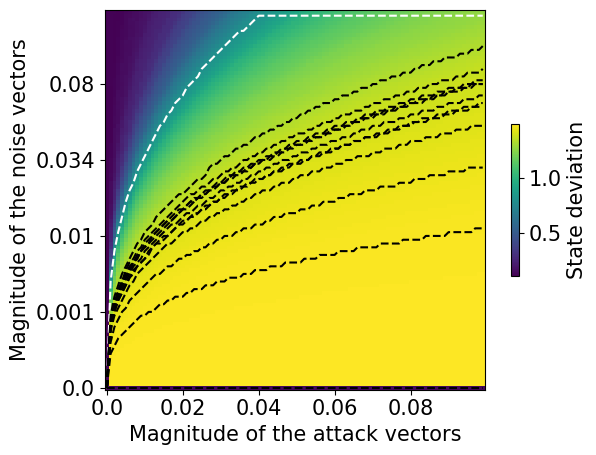

In [136]:
from matplotlib.colors import Normalize
plt.figure()
mapF1C=2*mapPrecisionC*mapRecalC/(mapRecalC+mapPrecisionC+1e-5)
mapF1All=2*mapPrecisionAll*mapRecalAll/(mapRecalAll+mapPrecisionAll+1e-5)


heatToShow= mapF1All[0, ...]# 

plotHere= plt.imshow(heatToShow, cmap=  "viridis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
f1CAll= (mapF1All[0, ...]>0.8).sum(axis= 0)
f1CAll[f1CAll>98.5]= 98
plt.plot(f1CAll, linestyle='dashed',  color= "white")

f1CAll= (mapF1C[:, ...]>0.8).sum(axis= 1)
f1CAll[f1CAll>98.5]= 98
plt.plot(f1CAll.T, linestyle='dashed',  color= "black")

colorbar =plt.colorbar(label= "State deviation", shrink=0.4)
colorbar.ax.tick_params(labelsize=15)
plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})
plt.ylabel("Magnitude of the noise vectors")
plt.xlabel("Magnitude of the attack vectors")
plt.tight_layout()
plt.show()

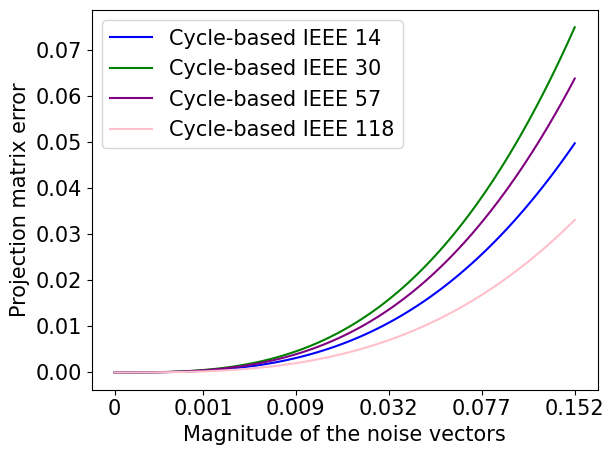

In [226]:
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
colors= ["blue", "green", "purple", "pink"]
for i in range(len(lossCycles)):
    plt.plot(lossCycles[i], label= f"Cycle-based {IEEENames[i]}", color= colors[i])
    # plt.plot(lossSVDs[i], "--", label= f"SVD-based {IEEENames[i]}",  color= colors[i])
# plt.yscale("log")
plt.xticks(ticks= [0]+[19+i*20 for i in range(5)], labels= [0]+[y_axis_label[19+i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})
plt.xlabel("Magnitude of the noise vectors")
plt.ylabel("Projection matrix error")
plt.legend()
plt.tight_layout()

In [202]:
lossCycles.append(lossCycle)
lossSVDs.append(lossSVD)

In [185]:
lossCycles= []
lossSVDs= []

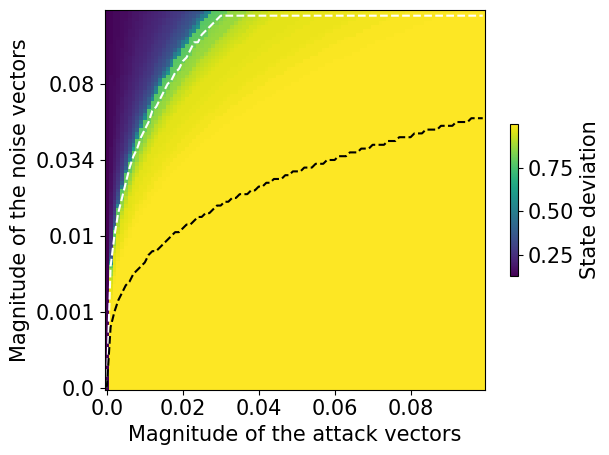

In [138]:
from matplotlib.colors import Normalize
plt.figure()
f1C= 2*mapPrecisionC*mapRecalC/(mapRecalC+mapPrecisionC+1e-5)
f1H= 2*mapPrecisionH*mapRecalH/(mapRecalH+mapPrecisionH+1e-5)

heatToShow= f1C# mapImpact, f1

plotHere= plt.imshow(heatToShow, cmap=  "viridis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
f1Csum= (f1C>0.8).sum(axis= 0)
f1Hsum= (f1H>0.8).sum(axis= 0)
# impact05= (mapImpact<0.05).sum(axis= 0)
# impact05[impact05>99.5]= 99
f1Csum[f1Csum>98.5]= 98
f1Hsum[f1Hsum>98.5]= 98
plt.plot(f1Csum, linestyle='dashed',  color= "white")
plt.plot(f1Hsum, linestyle='dashed', color= "black")
# plt.plot(impact05, linestyle='dashed', color= "red")
colorbar =plt.colorbar(label= "State deviation", shrink=0.4)
colorbar.ax.tick_params(labelsize=15)
plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})
plt.ylabel("Magnitude of the noise vectors")
plt.xlabel("Magnitude of the attack vectors")
plt.tight_layout()
# plt.title("F1")
plt.show()

56
746


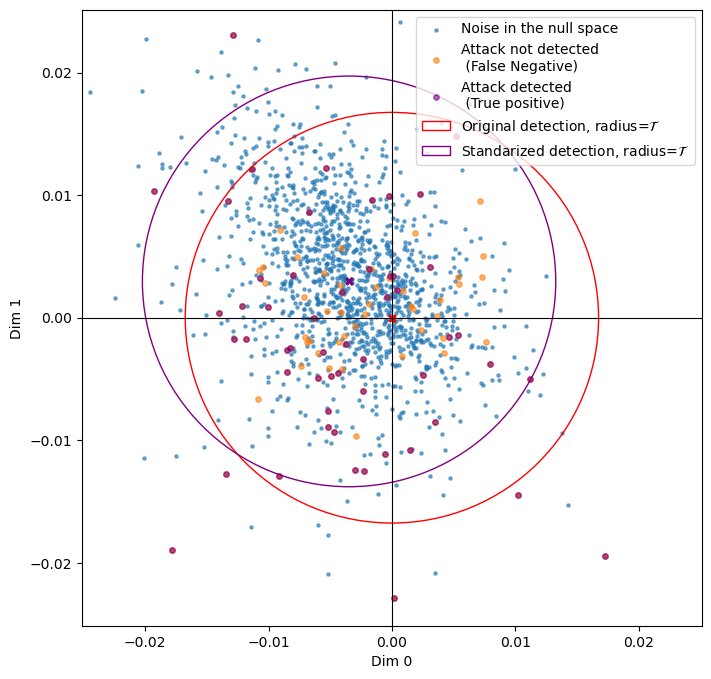

In [217]:
nullH2D= nullH[:, [6, 1]]# 6, 10, 11

tau= threshold_li(residualH)
limRange= tau*1.5
visul2D= nullH2D.T@pfDatanor.T
center2= nullH2D.T@(np.mean(pfDatanor, 0, keepdims= True).T)
center2= (center2[0], center2[1])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(visul2D[0, attackPeriod==0], visul2D[1, attackPeriod==0], s= 5, alpha=0.6, label= "Noise in the null space")
attackDetc= residualH>tau
cross= np.sum(attackDetc*(attackPeriod>1e-5))
negcross= np.sum((1-attackDetc)*(1-attackPeriod>1e-5))
print(cross)
print(negcross)
ax.scatter(visul2D[0, attackPeriod>1e-5], visul2D[1, attackPeriod>1e-5], s= 15, alpha=0.6, label= "Attack not detected \n (False Negative)")

ax.scatter(visul2D[0, attackDetc*(attackPeriod>1e-5)], visul2D[1, attackDetc*(attackPeriod>1e-5)], s= 15, alpha=0.6,  color='purple', label= "Attack detected \n (True positive)")

circle1= plt.Circle((0, 0), radius= tau, color='red', fill=False, linewidth=1, label= "Original detection, radius=$\mathcal{T}$")
ax.add_patch(circle1)
circle2= plt.Circle(center2, radius= tau, color='purple', fill=False, linewidth=1, label= "Standarized detection, radius=$\mathcal{T}$")
ax.add_patch(circle2)
ax.scatter(0, 0, s= 40, alpha=1, color='red', marker= "X", linewidths= 0.01)
ax.scatter(center2[0], center2[1], s= 40, alpha=1, color='purple', marker= "X", linewidths= 0.01)
plt.xlabel("Dim 0")
plt.ylabel("Dim 1")
plt.axhline(0, color='black', linewidth=0.8)  # x-axis
plt.axvline(0, color='black', linewidth=0.8)  # y-axis
plt.xlim(-limRange, limRange)
plt.ylim(-limRange, limRange)
plt.legend()

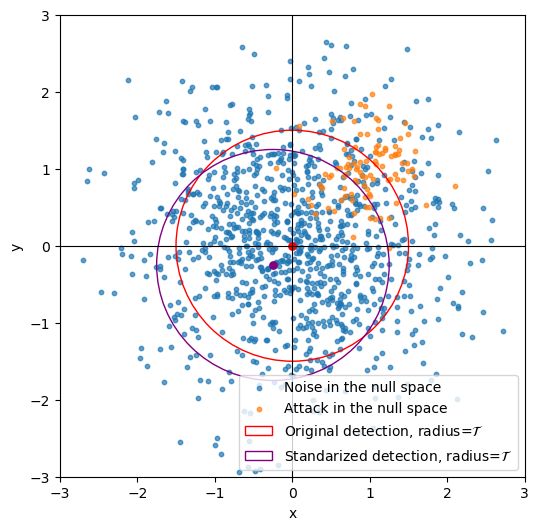

In [178]:
# Set random seed for reproducibility (optional)
np.random.seed(42)
biasXY= (1, 1)

# Sample 100 points from a Gaussian distribution with mean=0, variance=1
x = np.random.normal(loc=0.0, scale=1.0, size=1000)
y = np.random.normal(loc=0.0, scale=1.0, size=1000)

xA = np.random.normal(loc=0.0, scale=0.4, size=100)+biasXY[0]
yA = np.random.normal(loc=0.0, scale=0.4, size=100)+biasXY[1]

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s= 10, alpha=0.7, label= "Noise in the null space")
ax.scatter(xA, yA, s= 10, alpha=0.7, label= "Attack in the null space")
ax.scatter(0, 0, s= 40, alpha=1, color='red', marker= "o", linewidths= 0.01)
circle1= plt.Circle((0, 0), radius=1.5, color='red', fill=False, linewidth=1, label= "Original detection, radius=$\mathcal{T}$")
center2= (-biasXY[0]/4, -biasXY[1]/4)
ax.scatter(center2[0], center2[1], s= 40, alpha=1, color='purple', marker= "o", linewidths= 0.01)
circle2= plt.Circle(center2, radius=1.5, color='purple', fill=False, linewidth=1, label= "Standarized detection, radius=$\mathcal{T}$")
ax.add_patch(circle1)
ax.add_patch(circle2)
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.8)  # x-axis
plt.axvline(0, color='black', linewidth=0.8)  # y-axis

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid(False)
plt.legend()
plt.show()

num links
20
20
num links


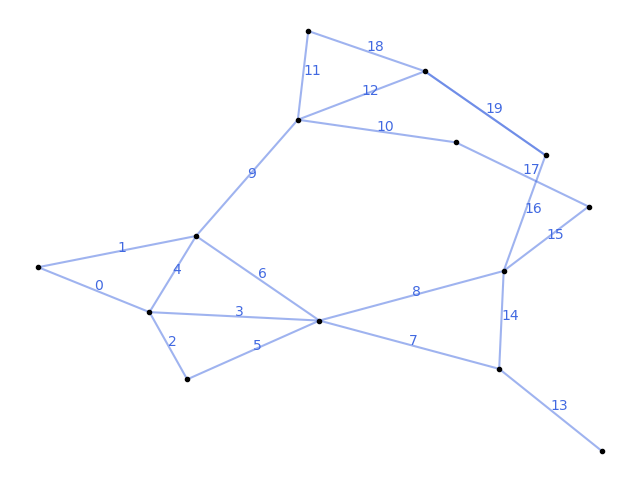

In [76]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
G, _= graph.from_A_to_G(A[:, :])
print("num links")
print(G.number_of_edges())
print(m)
print("num links")
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))

plotGraph.plot_spring_layout(G, label= False, label_edge= True, node_pair2id= node_pair2id)